## Chocolate Sales
---
format: 
    html:
        page-layout: full
        embed_resources: false
        grid: 
            body-width: 800px
            fontsize: 18pt
echo: true
warning: false
toc: True
---

![various chocolate bars](https://images.pexels.com/photos/4113305/pexels-photo-4113305.jpeg)
<sup>Author: Alleksana, pexels.com</sup>

In [2]:
# | echo: false

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold


## Cleaning Dataset

In [3]:
# | echo: false
or_df = pd.read_csv("Chocolate Sales (2).csv")
or_df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [4]:
# | echo: false
or_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


In [5]:
# removing "$"
or_df["Amount"] = (
    or_df["Amount"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
or_df["Date"] = pd.to_datetime(or_df["Date"], dayfirst=True)
# creating date features
or_df["Year"] = or_df["Date"].dt.year
or_df["Month"] = or_df["Date"].dt.month
or_df["Month Label"] = or_df["Date"].dt.strftime("%Y-%m")
or_df["Quarter"] = "Q" + or_df["Date"].dt.quarter.astype(str)

or_df["Product"] = or_df["Product"].replace({
    'Smooth Sliky Salty': 'Smooth Silky Salty',
    'Drinking Coco': 'Drinking Choco'
})


In [6]:
or_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   3282 non-null   object        
 1   Country        3282 non-null   object        
 2   Product        3282 non-null   object        
 3   Date           3282 non-null   datetime64[ns]
 4   Amount         3282 non-null   float64       
 5   Boxes Shipped  3282 non-null   int64         
 6   Year           3282 non-null   int64         
 7   Month          3282 non-null   int64         
 8   Month Label    3282 non-null   object        
 9   Quarter        3282 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(5)
memory usage: 256.5+ KB


In [7]:
# saving clean dataset
or_df.to_csv("chocolate_sales_clean.csv", index=False)

## Exploratory Data Analysis

In [8]:
# | echo: false
df = pd.read_csv("chocolate_sales_clean.csv")
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Year,Month,Month Label,Quarter
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.0,180,2022,1,2022-01,Q1
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94,2022,8,2022-08,Q3
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91,2022,7,2022-07,Q3
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342,2022,4,2022-04,Q2
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.0,184,2022,2,2022-02,Q1


In [9]:
# | echo: false
# converting date to datetime
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

#### Overview for whole dataset

In [10]:
# | echo: false
print(f" Sales Persons: {df['Sales Person'].unique()}\n")
print(f" Countries: {df['Country'].unique()}\n")
print(f" Products: {df['Product'].unique()}\n")
print(f" Range: {df['Date'].min()} - {df['Date'].max()}")

 Sales Persons: ['Jehu Rudeforth' 'Van Tuxwell' 'Gigi Bohling' 'Jan Morforth' 'Oby Sorrel'
 'Gunar Cockshoot' 'Brien Boise' 'Rafaelita Blaksland' 'Barr Faughny'
 'Mallorie Waber' 'Karlen McCaffrey' "Marney O'Breen" 'Beverie Moffet'
 'Roddy Speechley' 'Curtice Advani' 'Husein Augar' 'Kaine Padly'
 'Dennison Crosswaite' "Wilone O'Kielt" 'Andria Kimpton' 'Kelci Walkden'
 'Camilla Castle' 'Madelene Upcott' 'Dotty Strutley' 'Ches Bonnell']

 Countries: ['UK' 'India' 'Australia' 'New Zealand' 'USA' 'Canada']

 Products: ['Mint Chip Choco' '85% Dark Bars' 'Peanut Butter Cubes'
 'Smooth Silky Salty' '99% Dark & Pure' 'After Nines' '50% Dark Bites'
 'Orange Choco' 'Eclairs' 'Drinking Choco' 'Organic Choco Syrup'
 'Milk Bars' 'Spicy Special Slims' 'Fruit & Nut Bars' 'White Choc'
 'Manuka Honey Choco' 'Almond Choco' 'Raspberry Choco'
 'Choco Coated Almonds' "Baker's Choco Chips" 'Caramel Stuffed Bars'
 '70% Dark Bites']

 Range: 2022-01-03 00:00:00 - 2024-08-31 00:00:00


#### Overview for Years

In [11]:
# | echo: false
filtered_2022 = df[df["Year"] == 2022]
filtered_2023 = df[df["Year"] == 2023]
filtered_2024 = df[df["Year"] == 2024]

print("Earliest dates: ")
print(filtered_2022["Date"].min())
print(filtered_2023["Date"].min())
print(filtered_2024["Date"].min())
print("\nLatest dates: ")
print(filtered_2022["Date"].max())
print(filtered_2023["Date"].max())
print(filtered_2024["Date"].max())

print("\nSalesmen list for year 2022:")
print(filtered_2022["Sales Person"].unique())
print("\nSalesmen list for year 2023:")
print(filtered_2023["Sales Person"].unique())
print("\nSalesmen list for year 2024:")
print(filtered_2024["Sales Person"].unique())

print("\nProduct list for 2022: ")
print(filtered_2022["Product"].unique())
print("\nProduct list for 2023: ")
print(filtered_2023["Product"].unique())
print("\nProduct list for 2024: ")
print(filtered_2024["Product"].unique())

print("\nCountries list for year 2022: ")
print(filtered_2022["Country"].unique())
print("\nCountries list for year 2023: ")
print(filtered_2023["Country"].unique())
print("\nCountries list for year 2024: ")
print(filtered_2024["Country"].unique())

Earliest dates: 
2022-01-03 00:00:00
2023-01-03 00:00:00
2024-01-03 00:00:00

Latest dates: 
2022-08-31 00:00:00
2023-08-31 00:00:00
2024-08-31 00:00:00

Salesmen list for year 2022:
['Jehu Rudeforth' 'Van Tuxwell' 'Gigi Bohling' 'Jan Morforth' 'Oby Sorrel'
 'Gunar Cockshoot' 'Brien Boise' 'Rafaelita Blaksland' 'Barr Faughny'
 'Mallorie Waber' 'Karlen McCaffrey' "Marney O'Breen" 'Beverie Moffet'
 'Roddy Speechley' 'Curtice Advani' 'Husein Augar' 'Kaine Padly'
 'Dennison Crosswaite' "Wilone O'Kielt" 'Andria Kimpton' 'Kelci Walkden'
 'Camilla Castle' 'Madelene Upcott' 'Dotty Strutley' 'Ches Bonnell']

Salesmen list for year 2023:
['Jehu Rudeforth' 'Van Tuxwell' 'Gigi Bohling' 'Jan Morforth' 'Oby Sorrel'
 'Gunar Cockshoot' 'Brien Boise' 'Rafaelita Blaksland' 'Barr Faughny'
 'Mallorie Waber' 'Karlen McCaffrey' "Marney O'Breen" 'Beverie Moffet'
 'Roddy Speechley' 'Curtice Advani' 'Husein Augar' 'Kaine Padly'
 'Dennison Crosswaite' "Wilone O'Kielt" 'Andria Kimpton' 'Kelci Walkden'
 'Camilla 

In [12]:
filtered_2024.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1094 entries, 2188 to 3281
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   1094 non-null   object        
 1   Country        1094 non-null   object        
 2   Product        1094 non-null   object        
 3   Date           1094 non-null   datetime64[ns]
 4   Amount         1094 non-null   float64       
 5   Boxes Shipped  1094 non-null   int64         
 6   Year           1094 non-null   int64         
 7   Month          1094 non-null   int64         
 8   Month Label    1094 non-null   object        
 9   Quarter        1094 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(5)
memory usage: 94.0+ KB


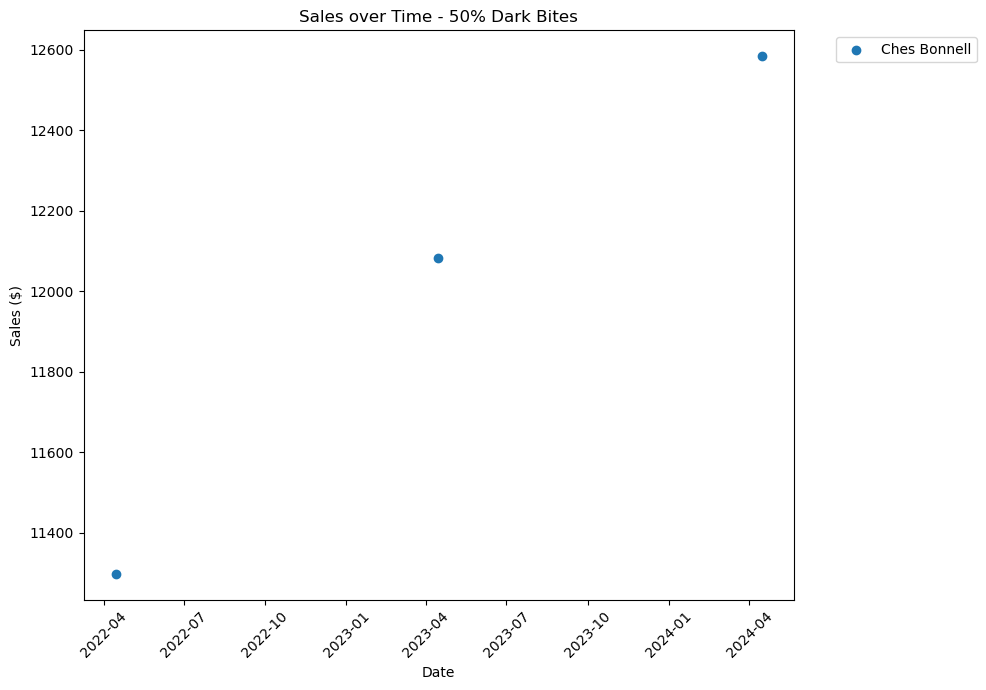

In [13]:
# | echo: false
salesman = "Ches Bonnell"
product = "50% Dark Bites"

# filter data
filtered = df[
    (df["Sales Person"] == salesman) &
    (df["Product"] == product)
]

# scatter plot
plt.figure(figsize=(10,7))
plt.scatter(filtered["Date"], filtered["Amount"], label="Ches Bonnell")

plt.title(f"Sales over Time - {product}")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

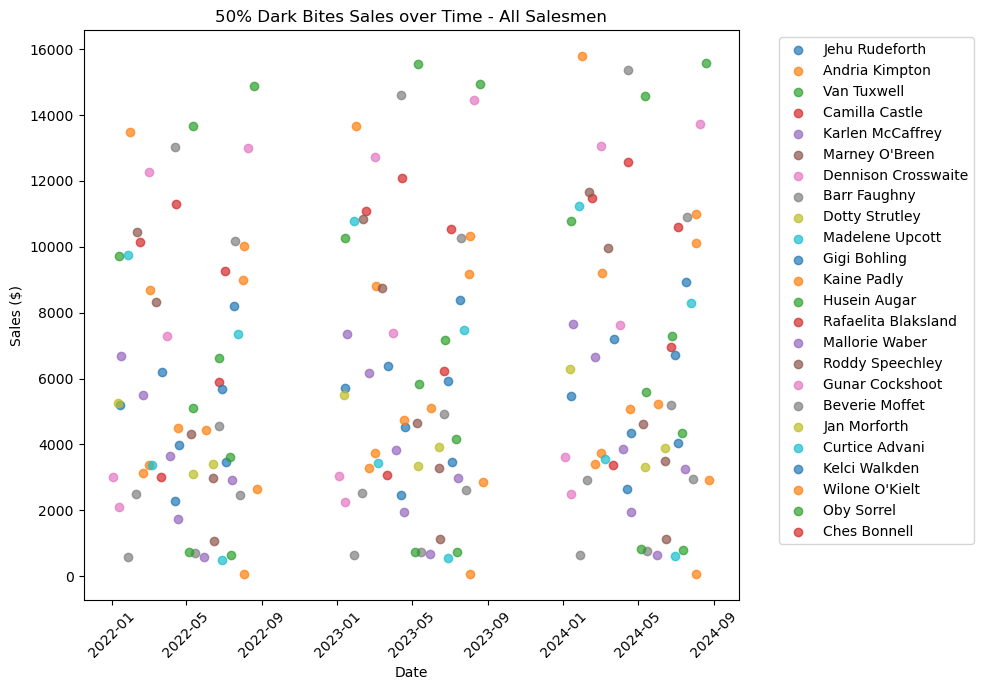

In [14]:
# | echo: false
product = "50% Dark Bites"

filtered = df[df["Product"] == product]

plt.figure(figsize=(10, 7))

for person in filtered["Sales Person"].unique():
    person_data = filtered[filtered["Sales Person"] == person]

    plt.scatter(
        person_data["Date"],
        person_data["Amount"],
        label=person,
        alpha=0.7
    )

plt.title(f"{product} Sales over Time - All Salesmen")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

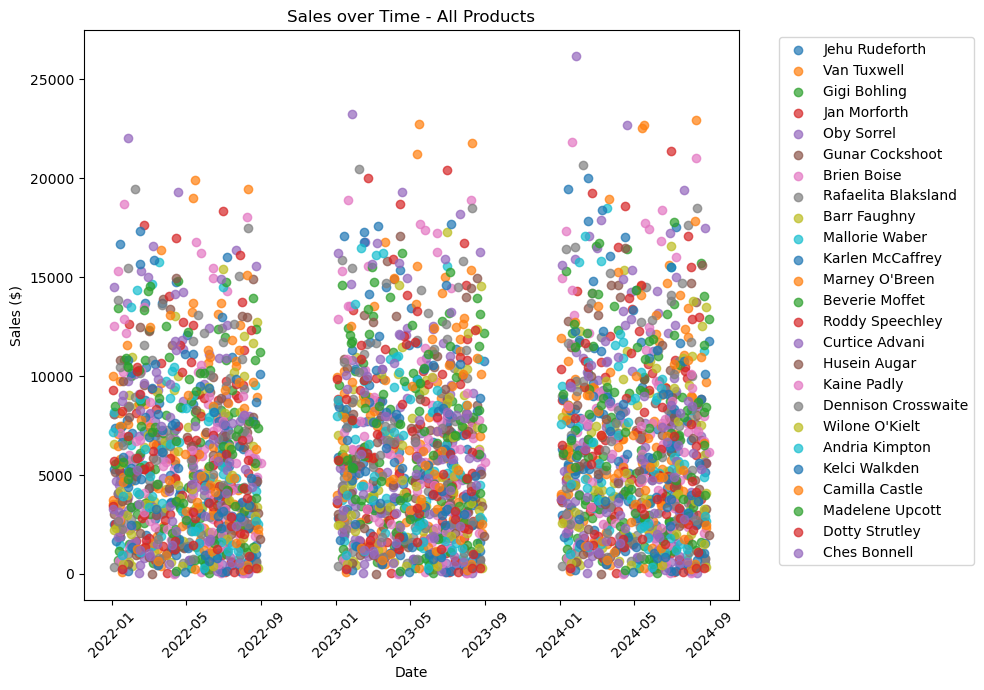

In [15]:
# | echo: false
plt.figure(figsize=(10, 7))

for person in df["Sales Person"].unique():
    person_data = df[df["Sales Person"] == person]

    plt.scatter(
        person_data["Date"],
        person_data["Amount"],
        label=person,
        alpha=0.7
    )

plt.title("Sales over Time - All Products")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Random Forrest Regressor Model

#### Cross Validation

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
amount_mae_list = []
boxes_mae_list = []

amount_pct_list = []
boxes_pct_list = []

for train_idx, test_idx in kf.split(df):

    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    # --- feature engineering
    global_avg = train_df["Amount"].mean()

    product_avg = train_df.groupby("Product")["Amount"].mean()
    person_avg = train_df.groupby("Sales Person")["Amount"].mean()
    country_avg = train_df.groupby("Country")["Amount"].mean()
    year_avg = train_df.groupby("Year")["Amount"].mean()
    quarter_avg = train_df.groupby("Quarter")["Amount"].mean()

    product_country_avg = train_df.groupby(["Product", "Country"])["Amount"].mean()
    product_person_avg = train_df.groupby(["Product", "Sales Person"])["Amount"].mean()
    product_year_avg = train_df.groupby(["Product", "Year"])["Amount"].mean()
    product_month_avg = train_df.groupby(["Product", "Month"])["Amount"].mean()

    person_country_avg = train_df.groupby(["Sales Person", "Country"])["Amount"].mean()

    

    def add_features(data):
        out = data.copy()
        
        out["product_avg"] = out["Product"].map(product_avg).fillna(global_avg)
        out["person_avg"] = out["Sales Person"].map(person_avg).fillna(global_avg)
        out["country_avg"] = out["Country"].map(country_avg).fillna(global_avg)
        out["year_avg"] = out["Year"].map(year_avg).fillna(global_avg)
        out["quarter_avg"] = out["Quarter"].map(quarter_avg).fillna(global_avg)

        out["product_country_avg"] = out.apply(
            lambda row: product_country_avg.get((row["Product"], row["Country"]), global_avg),
            axis=1
        )

        out["product_person_avg"] = out.apply(
            lambda row: product_person_avg.get((row["Product"], row["Sales Person"]), global_avg),
            axis=1
        )

        out["product_year_avg"] = out.apply(
            lambda row: product_year_avg.get((row["Product"], row["Year"]), global_avg),
            axis=1
        )

        out["product_month_avg"] = out.apply(
            lambda row: product_month_avg.get((row["Product"], row["Month"]), global_avg),
            axis=1
        )

        out["person_country_avg"] = out.apply(
            lambda row: person_country_avg.get((row["Sales Person"], row["Country"]), global_avg),
            axis=1
        )

        return out

    train_feat = add_features(train_df)
    test_feat = add_features(test_df)

    X_train = train_feat[
        [
         "quarter_avg",
         "product_avg",
         "person_avg",
         "country_avg",
         "product_country_avg",
         "product_person_avg",
         "product_month_avg",
         "person_country_avg",
         ]
    ]

    X_test = test_feat[
        [
         "quarter_avg",
         "product_avg",
         "person_avg",
         "country_avg",
         "product_country_avg",
         "product_person_avg",
         "product_month_avg",
         "person_country_avg",
         ]
    ]

    X_train = pd.get_dummies(X_train, columns=[])
    X_test = pd.get_dummies(X_test, columns=[])
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

    y_train = train_feat[["Amount", "Boxes Shipped"]]
    y_test = test_feat[["Amount", "Boxes Shipped"]]

    model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    # --- separate MAE ---
    amount_mae = mean_absolute_error(y_test["Amount"], preds[:, 0])
    boxes_mae = mean_absolute_error(y_test["Boxes Shipped"], preds[:, 1])

    # --- percentage MAE ---
    amount_pct = amount_mae / y_test["Amount"].mean()
    boxes_pct = boxes_mae / y_test["Boxes Shipped"].mean()

    amount_mae_list.append(amount_mae)
    boxes_mae_list.append(boxes_mae)

    amount_pct_list.append(amount_pct)
    boxes_pct_list.append(boxes_pct)

# --- results ---
print("Amount MAE:", np.mean(amount_mae_list))
print(f"Amount MAE %: {np.mean(amount_pct_list):.2%}")

print("Boxes Shipped MAE:", np.mean(boxes_mae_list))
print(f"Boxes Shipped MAE %: {np.mean(boxes_pct_list):.2%}")

Amount MAE: 969.5174463646996
Amount MAE %: 16.11%
Boxes Shipped MAE: 26.242845794965024
Boxes Shipped MAE %: 15.93%


#### Final Evaluation

In [17]:
# separate actual values
y_test_amount = y_test["Amount"]
y_test_boxes = y_test["Boxes Shipped"]

# separate predictions
pred_amount = preds[:, 0]
pred_boxes = preds[:, 1]

# --- MAE ---
mae_amount = mean_absolute_error(y_test_amount, pred_amount)
mae_boxes = mean_absolute_error(y_test_boxes, pred_boxes)

# --- MAE % ---
mae_amount_pct = mae_amount / y_test_amount.mean()
mae_boxes_pct = mae_boxes / y_test_boxes.mean()

# --- print ---
print("Amount MAE:", mae_amount)
print(f"Amount MAE %: {mae_amount_pct:.2%}")

print("Boxes Shipped MAE:", mae_boxes)
print(f"Boxes Shipped MAE %: {mae_boxes_pct:.2%}")

Amount MAE: 1017.9156493495273
Amount MAE %: 15.87%
Boxes Shipped MAE: 26.065975852822646
Boxes Shipped MAE %: 15.90%


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   3282 non-null   object        
 1   Country        3282 non-null   object        
 2   Product        3282 non-null   object        
 3   Date           3282 non-null   datetime64[ns]
 4   Amount         3282 non-null   float64       
 5   Boxes Shipped  3282 non-null   int64         
 6   Year           3282 non-null   int64         
 7   Month          3282 non-null   int64         
 8   Month Label    3282 non-null   object        
 9   Quarter        3282 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(5)
memory usage: 256.5+ KB


## Synthetic Data for 2025

In [21]:
base = df[["Product", "Sales Person", "Country"]].drop_duplicates()
hist = df[df["Month"].between(3, 8)]

future_2025 = hist.sample(n=1094, replace=True, random_state=42).copy()

date_range = pd.date_range("2025-03-01", "2025-08-31")

future_2025["Date"] = np.random.RandomState(42).choice(date_range, size=len(future_2025))
future_2025["Date"] = pd.to_datetime(future_2025["Date"])

future_2025["Year"] = future_2025["Date"].dt.year
future_2025["Month"] = future_2025["Date"].dt.month
future_2025["Month Label"] = future_2025["Date"].dt.strftime("%Y-%m")
future_2025["Quarter"] = "Q" + future_2025["Date"].dt.quarter.astype(str)

future_2025.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Year,Month,Month Label,Quarter
1136,Mallorie Waber,Canada,Choco Coated Almonds,2025-06-11,5345.58,250,2025,6,2025-06,Q2
1712,Karlen McCaffrey,India,85% Dark Bars,2025-08-27,1036.77,82,2025,8,2025-08,Q3
1489,Brien Boise,USA,Organic Choco Syrup,2025-06-01,17383.08,145,2025,6,2025-06,Q2
1435,Karlen McCaffrey,Canada,Spicy Special Slims,2025-03-15,6315.53,51,2025,3,2025-03,Q1
2162,Madelene Upcott,Canada,Milk Bars,2025-06-15,3907.50,86,2025,6,2025-06,Q2


In [22]:
earliest=future_2025['Date'].min()
display(earliest)
latest=future_2025['Date'].max()
display(latest)
display(future_2025['Product'].unique())
display(future_2025['Sales Person'].unique())
display(future_2025.info())

Timestamp('2025-03-01 00:00:00')

Timestamp('2025-08-31 00:00:00')

array(['Choco Coated Almonds', '85% Dark Bars', 'Organic Choco Syrup',
       'Spicy Special Slims', 'Milk Bars', 'Drinking Choco',
       '99% Dark & Pure', 'After Nines', 'Almond Choco',
       'Smooth Silky Salty', 'White Choc', '50% Dark Bites',
       'Caramel Stuffed Bars', 'Fruit & Nut Bars', 'Eclairs',
       "Baker's Choco Chips", 'Raspberry Choco', 'Mint Chip Choco',
       'Manuka Honey Choco', 'Orange Choco', 'Peanut Butter Cubes',
       '70% Dark Bites'], dtype=object)

array(['Mallorie Waber', 'Karlen McCaffrey', 'Brien Boise',
       'Madelene Upcott', 'Kaine Padly', 'Gigi Bohling', 'Dotty Strutley',
       'Kelci Walkden', 'Roddy Speechley', 'Oby Sorrel',
       'Dennison Crosswaite', 'Beverie Moffet', 'Ches Bonnell',
       'Andria Kimpton', 'Van Tuxwell', 'Curtice Advani',
       'Jehu Rudeforth', 'Camilla Castle', 'Rafaelita Blaksland',
       'Husein Augar', 'Barr Faughny', 'Jan Morforth', 'Gunar Cockshoot',
       "Wilone O'Kielt", "Marney O'Breen"], dtype=object)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1094 entries, 1136 to 2318
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   1094 non-null   object        
 1   Country        1094 non-null   object        
 2   Product        1094 non-null   object        
 3   Date           1094 non-null   datetime64[ns]
 4   Amount         1094 non-null   float64       
 5   Boxes Shipped  1094 non-null   int64         
 6   Year           1094 non-null   int64         
 7   Month          1094 non-null   int64         
 8   Month Label    1094 non-null   object        
 9   Quarter        1094 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(5)
memory usage: 94.0+ KB


None